## Netflix Dataset Analysis

### 1. Load Data and Initial Exploration

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from the local file
print("Attempting to load Netflix dataset from 'netflix_titles.csv'...")
try:
    df = pd.read_csv('netflix_titles.csv')
    print("Netflix dataset loaded successfully from local file.")
except FileNotFoundError:
    print("Error: 'netflix_titles.csv' not found. Please ensure the file is present in the current directory.")
    df = pd.DataFrame() # Create an empty DataFrame if file not found
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")
    df = pd.DataFrame() # Create an empty DataFrame if an error occurs

if not df.empty:
    print("Dataset loaded successfully.")
    display(df.head())
    display(df.info())
    display(df.describe(include='all'))
else:
    print("No data loaded. Please ensure the dataset is available or provide a correct path/URL.")

Attempting to load Netflix dataset from 'netflix_titles.csv'...
Netflix dataset loaded successfully from local file.
Dataset loaded successfully.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


None

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### 2. Data Cleaning and Preparation

Based on the `df.info()` output, we might need to handle missing values, convert data types, and potentially create new features for analysis.

In [4]:
if not df.empty:
    # Convert 'date_added' to datetime objects
    df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

    # Extract year added for trend analysis
    df['year_added'] = df['date_added'].dt.year

    # Fill missing 'country' with 'Unknown' (or mode, depending on analysis goal)
    df['country'].fillna('Unknown', inplace=True)

    # Fill missing 'rating' with mode
    df['rating'].fillna(df['rating'].mode()[0], inplace=True)

    # Drop rows where 'date_added' could not be parsed (if any)
    df.dropna(subset=['date_added'], inplace=True)

    print("\nAfter cleaning and preparation:")
    display(df.info())
    display(df.head())
else:
    print("Cannot perform data cleaning as no data was loaded.")


After cleaning and preparation:
<class 'pandas.core.frame.DataFrame'>
Index: 8709 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8709 non-null   object        
 1   type          8709 non-null   object        
 2   title         8709 non-null   object        
 3   director      6168 non-null   object        
 4   cast          7892 non-null   object        
 5   country       8709 non-null   object        
 6   date_added    8709 non-null   datetime64[ns]
 7   release_year  8709 non-null   int64         
 8   rating        8709 non-null   object        
 9   duration      8706 non-null   object        
 10  listed_in     8709 non-null   object        
 11  description   8709 non-null   object        
 12  year_added    8709 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(10)
memory usage: 952.5+ KB


/tmp/ipykernel_4966/2055335175.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['country'].fillna('Unknown', inplace=True)
/tmp/ipykernel_4966/2055335175.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

None

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0


### 3. Summary Statistics

Now we can look at summary statistics of key categorical and numerical features.

In [5]:
if not df.empty:
    print("\nSummary statistics for key columns:")
    display(df['type'].value_counts())
    display(df['rating'].value_counts())
    display(df['country'].value_counts().head(10))
    display(df['release_year'].describe())
    display(df['duration'].apply(lambda x: int(x.split(' ')[0]) if isinstance(x, str) and 'min' in x else None).dropna().describe()) # For movies duration
else:
    print("Cannot calculate summary statistics as no data was loaded.")


Summary statistics for key columns:


,count
type,
Movie,6131
TV Show,2578


,count
rating,
TV-MA,3187
TV-14,2133
TV-PG,838
R,799
PG-13,490
TV-Y7,330
TV-Y,300
PG,287
TV-G,212


,count
country,
United States,2778
India,971
Unknown,827
United Kingdom,403
Japan,241
South Korea,195
Canada,173
Spain,141
France,122


,release_year
count,8709.000000
mean,2014.197038
std,8.826219
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


,duration
count,6128.000000
mean,99.577187
std,28.290593
min,3.000000
25%,87.000000
50%,98.000000
75%,114.000000
max,312.000000


### 4. Trend Identification (Content Added Over Time)

Let's analyze the trends in content added to Netflix over the years.

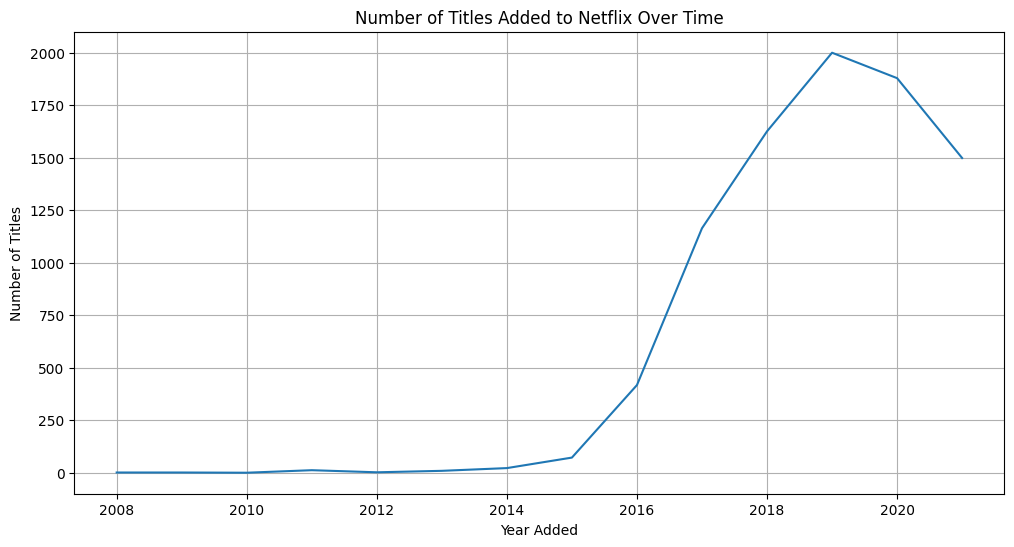

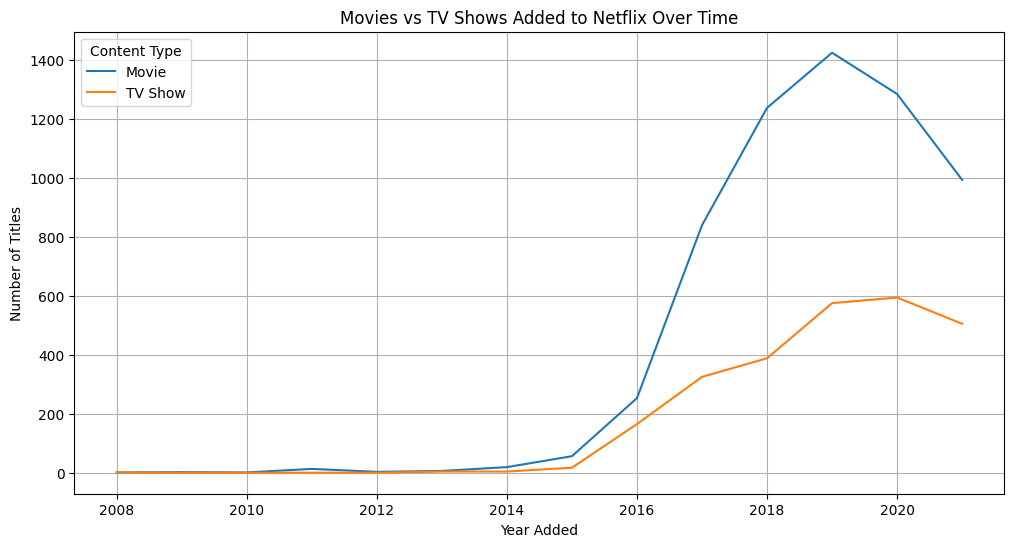

In [6]:
if not df.empty:
    content_added_by_year = df.groupby('year_added').size().reset_index(name='count')

    plt.figure(figsize=(12, 6))
    sns.lineplot(x='year_added', y='count', data=content_added_by_year)
    plt.title('Number of Titles Added to Netflix Over Time')
    plt.xlabel('Year Added')
    plt.ylabel('Number of Titles')
    plt.grid(True)
    plt.show()

    content_type_by_year = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)

    content_type_by_year.plot(kind='line', figsize=(12, 6))
    plt.title('Movies vs TV Shows Added to Netflix Over Time')
    plt.xlabel('Year Added')
    plt.ylabel('Number of Titles')
    plt.grid(True)
    plt.legend(title='Content Type')
    plt.show()
else:
    print("Cannot identify trends as no data was loaded.")

### 5. Correlation Analysis

For correlation analysis, we typically look at numerical features. In this dataset, `release_year` and `year_added` are the primary numerical candidates. We can also explore correlations between categorical features using methods like chi-squared tests or by visualizing their distributions.


Correlation matrix for numerical features:


,release_year,year_added
release_year,1.000000,0.110473
year_added,0.110473,1.000000


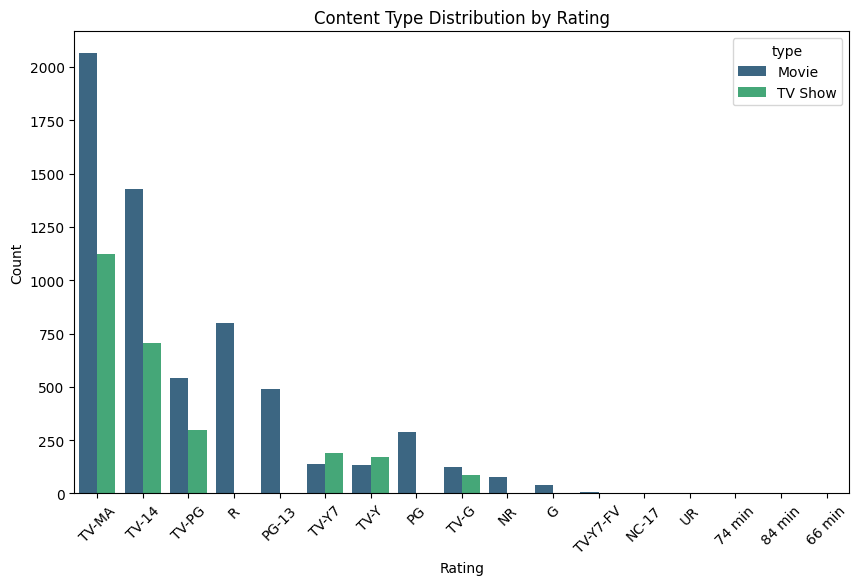

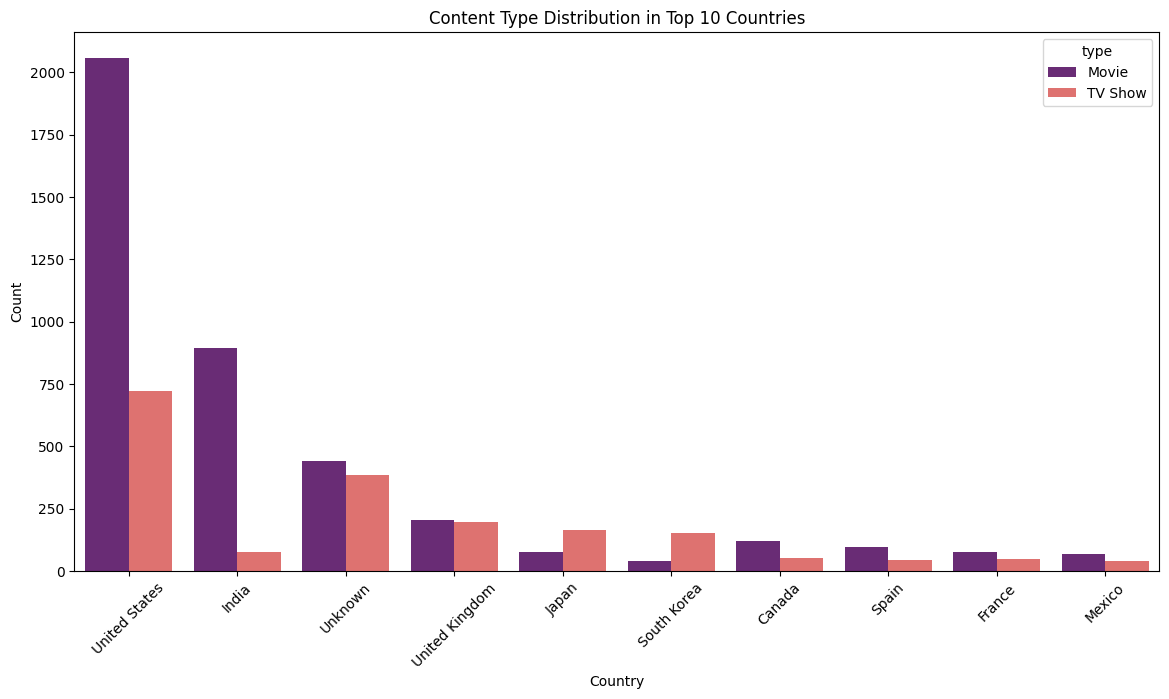

In [7]:
if not df.empty:
    # Numerical correlation (if more numerical features existed)
    numerical_df = df[['release_year', 'year_added']]
    print("\nCorrelation matrix for numerical features:")
    display(numerical_df.corr())

    # Example: Relationship between 'type' and 'rating'
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x='rating', hue='type', palette='viridis', order=df['rating'].value_counts().index)
    plt.title('Content Type Distribution by Rating')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

    # Example: Top 10 countries by content type
    top_countries = df['country'].value_counts().head(10).index
    df_top_countries = df[df['country'].isin(top_countries)]

    plt.figure(figsize=(14, 7))
    sns.countplot(data=df_top_countries, x='country', hue='type', palette='magma', order=top_countries)
    plt.title('Content Type Distribution in Top 10 Countries')
    plt.xlabel('Country')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Cannot perform correlation analysis as no data was loaded.")

### Next Steps / Further Exploration:

*   **Detailed Content Analysis**: Explore genres, directors, and actors to identify popular categories or collaborations.
*   **Duration Analysis**: Analyze movie durations and TV show season counts.
*   **Text Analysis**: For 'description' or 'listed_in' columns, natural language processing (NLP) techniques could reveal thematic trends.
*   **Audience Segmentation**: Combine rating with other features to infer audience preferences.